# Health Campaign Data Analysis

**Project:** Health Campaign Dashboard — Data Analyst Notebook
**Goal:** Follow a standard data analyst workflow (load → inspect → clean → transform → explore → visualize → summarize) to understand patterns in health campaign scheduling, duration, and category mix.

**Workflow stages in this notebook:**
1. Import libraries
2. Load the data
3. Initial data understanding (shape, types, missing values)
4. Data cleaning (dates, duplicates, missing values)
5. Feature engineering (duration, year, month)
6. Descriptive statistics / KPIs
7. Univariate analysis (categories)
8. Time-based analysis (trend, seasonality/heatmap)
9. Key insights & summary


## 1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Notebook display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded.")


Libraries loaded.


## 2. Load the Data

Update `DATA_PATH` to point to your CSV file.

In [21]:
df_raw = pd.read_csv("./data/Health_Camp_Detail.csv")
print(f"Loaded {df_raw.shape[0]} rows and {df_raw.shape[1]} columns")
df_raw.head()


Loaded 65 rows and 6 columns


,Health_Camp_ID,Camp_Start_Date,Camp_End_Date,Category1,Category2,Category3
0,6560,16-Aug-03,20-Aug-03,First,B,2
1,6530,16-Aug-03,28-Oct-03,First,C,2
2,6544,03-Nov-03,15-Nov-03,First,F,1
3,6585,22-Nov-03,05-Dec-03,First,E,2
4,6561,30-Nov-03,18-Dec-03,First,E,1


## 3. Initial Data Understanding

Before cleaning anything, get a feel for the data: structure, types, and obvious quality issues.

In [22]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Health_Camp_ID   65 non-null     int64 
 1   Camp_Start_Date  65 non-null     object
 2   Camp_End_Date    65 non-null     object
 3   Category1        65 non-null     object
 4   Category2        65 non-null     object
 5   Category3        65 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 3.2+ KB


In [23]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Health_Camp_ID,65.0,NaN,NaN,NaN,6555.0,18.90767,6523.0,6539.0,6555.0,6571.0,6587.0
Camp_Start_Date,65,58,16-Aug-03,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Camp_End_Date,65,54,07-Nov-07,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category1,65,3,First,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category2,65,7,C,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category3,65.0,NaN,NaN,NaN,1.953846,0.211451,1.0,2.0,2.0,2.0,2.0


In [24]:
# Missing values per column
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)


,missing_count,missing_pct
Health_Camp_ID,0,0.0
Camp_Start_Date,0,0.0
Camp_End_Date,0,0.0
Category1,0,0.0
Category2,0,0.0
Category3,0,0.0


In [25]:
# Duplicate rows
n_dupes = df_raw.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")


Duplicate rows: 0


## 4. Data Cleaning

Key cleaning steps:
- Parse `Camp_Start_Date` and `Camp_End_Date` as real datetimes (avoids pandas' "could not infer format" warning and prevents silent parsing errors).
- Drop rows where dates fail to parse, and rows that are exact duplicates.
- Flag/inspect any campaigns where the end date is before the start date (a likely data entry error).

In [26]:
df = df_raw.copy()

required_cols = {"Camp_Start_Date", "Camp_End_Date", "Category1", "Category2"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing expected column(s) in CSV: {missing_cols}")

# Parse dates explicitly. If you know the exact format (e.g. "%d-%b-%y"),
# replace format="mixed" with that string for faster, more predictable parsing.
df["Camp_Start_Date"] = pd.to_datetime(df["Camp_Start_Date"], format="mixed", dayfirst=True, errors="coerce")
df["Camp_End_Date"] = pd.to_datetime(df["Camp_End_Date"], format="mixed", dayfirst=True, errors="coerce")

# Drop rows with unparseable dates
bad_dates = df["Camp_Start_Date"].isna() | df["Camp_End_Date"].isna()
if bad_dates.any():
    print(f"Dropping {bad_dates.sum()} row(s) with unparseable dates")
    df = df[~bad_dates].copy()

# Drop exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate row(s)")

# Flag campaigns where end date precedes start date
invalid_range = df["Camp_End_Date"] < df["Camp_Start_Date"]
print(f"Campaigns with End_Date before Start_Date: {invalid_range.sum()}")
df.loc[invalid_range, ["Camp_Start_Date", "Camp_End_Date"]]


Dropped 0 duplicate row(s)
Campaigns with End_Date before Start_Date: 0


,Camp_Start_Date,Camp_End_Date


In [27]:
# Drop invalid date ranges (uncomment if you want to exclude them)
# df = df[~invalid_range].copy()

print(f"Rows remaining after cleaning: {len(df)}")
df.head()


Rows remaining after cleaning: 65


,Health_Camp_ID,Camp_Start_Date,Camp_End_Date,Category1,Category2,Category3
0,6560,2003-08-16,2003-08-20,First,B,2
1,6530,2003-08-16,2003-10-28,First,C,2
2,6544,2003-11-03,2003-11-15,First,F,1
3,6585,2003-11-22,2003-12-05,First,E,2
4,6561,2003-11-30,2003-12-18,First,E,1


## 5. Feature Engineering

Derive analysis-friendly fields from the raw dates.

In [28]:
df["Duration_Days"] = (df["Camp_End_Date"] - df["Camp_Start_Date"]).dt.days
df["Year"] = df["Camp_Start_Date"].dt.year
df["Month"] = df["Camp_Start_Date"].dt.month_name()
df["YearMonth"] = df["Camp_Start_Date"].dt.to_period("M").astype(str)

df[["Camp_Start_Date", "Camp_End_Date", "Duration_Days", "Year", "Month", "YearMonth"]].head()


,Camp_Start_Date,Camp_End_Date,Duration_Days,Year,Month,YearMonth
0,2003-08-16,2003-08-20,4,2003,August,2003-08
1,2003-08-16,2003-10-28,73,2003,August,2003-08
2,2003-11-03,2003-11-15,12,2003,November,2003-11
3,2003-11-22,2003-12-05,13,2003,November,2003-11
4,2003-11-30,2003-12-18,18,2003,November,2003-11


## 6. Descriptive Statistics / KPIs

High-level numbers that summarize the overall campaign dataset.

In [29]:
kpis = {
    "Total Campaigns": len(df),
    "Avg Duration (Days)": round(df["Duration_Days"].mean(), 1),
    "Median Duration (Days)": df["Duration_Days"].median(),
    "Longest Duration (Days)": df["Duration_Days"].max(),
    "Shortest Duration (Days)": df["Duration_Days"].min(),
    "Date Range": f"{df['Camp_Start_Date'].min().date()} to {df['Camp_Start_Date'].max().date()}",
}

for k, v in kpis.items():
    print(f"{k}: {v}")


Total Campaigns: 65
Avg Duration (Days): 95.3
Median Duration (Days): 13.0
Longest Duration (Days): 771
Shortest Duration (Days): 2
Date Range: 2003-08-16 to 2007-01-30


In [30]:
df["Duration_Days"].describe()


count     65.000000
mean      95.276923
std      184.159875
min        2.000000
25%        5.000000
50%       13.000000
75%       74.000000
max      771.000000
Name: Duration_Days, dtype: float64

## 7. Univariate Analysis

Distribution of campaigns across categories and duration.

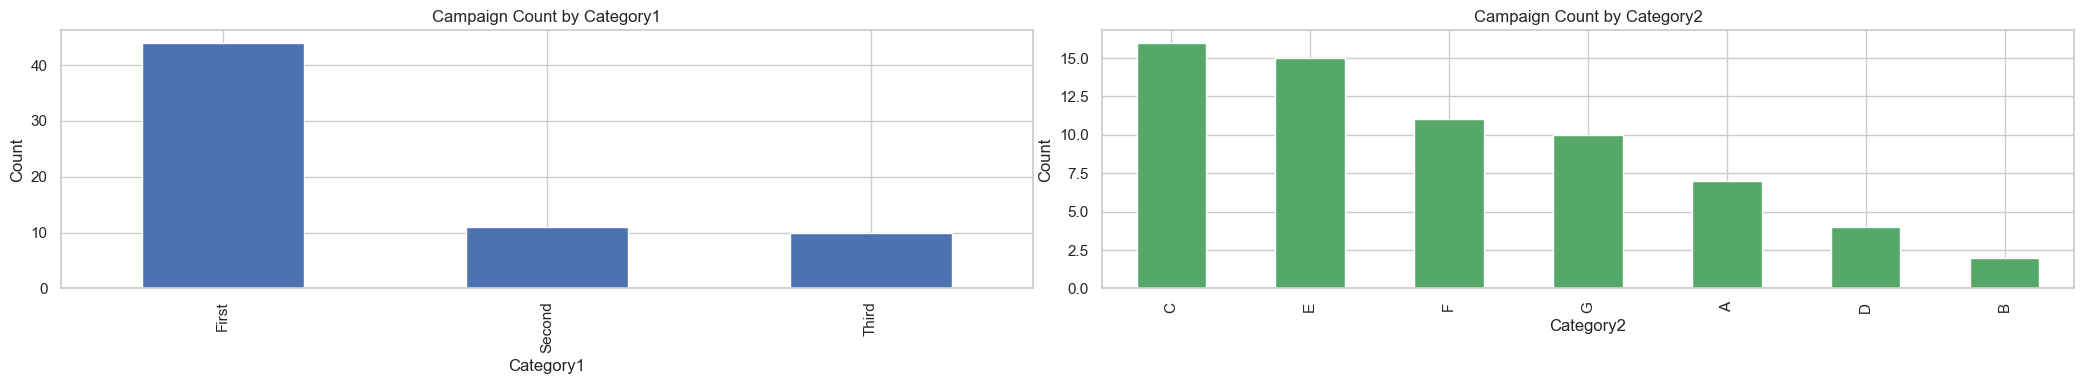

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(21, 4))

df["Category1"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Campaign Count by Category1")
axes[0].set_ylabel("Count")

df["Category2"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Campaign Count by Category2")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [32]:
fig = px.pie(df, names="Category1", title="Campaigns by Category1", hole=0.4)
fig.show()


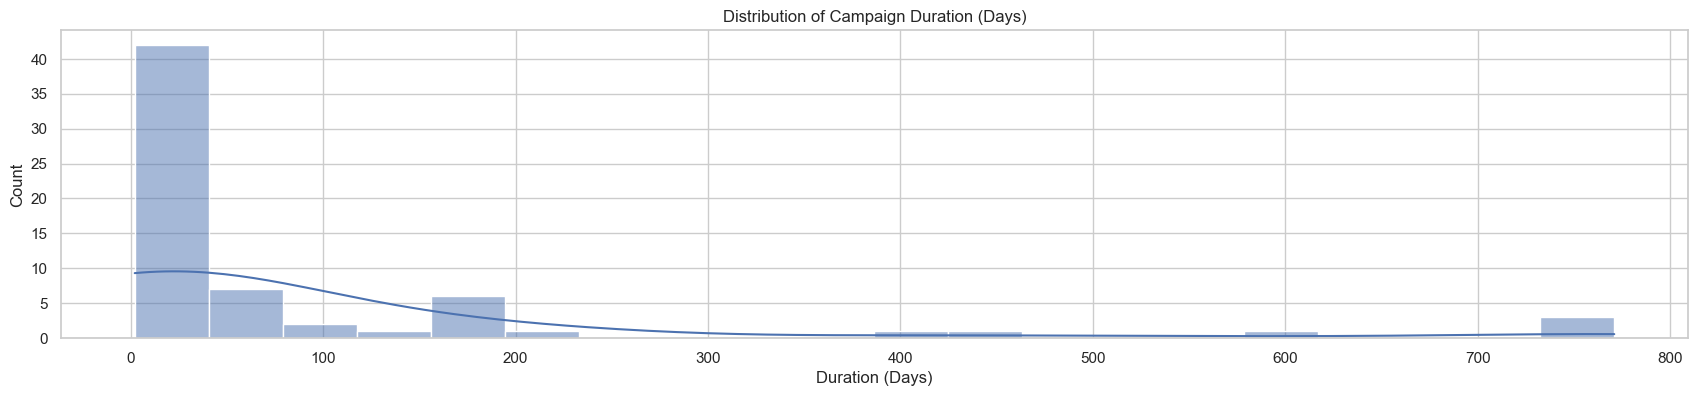

In [33]:
plt.figure(figsize=(21, 4))
sns.histplot(df["Duration_Days"], bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of Campaign Duration (Days)")
plt.xlabel("Duration (Days)")
plt.show()


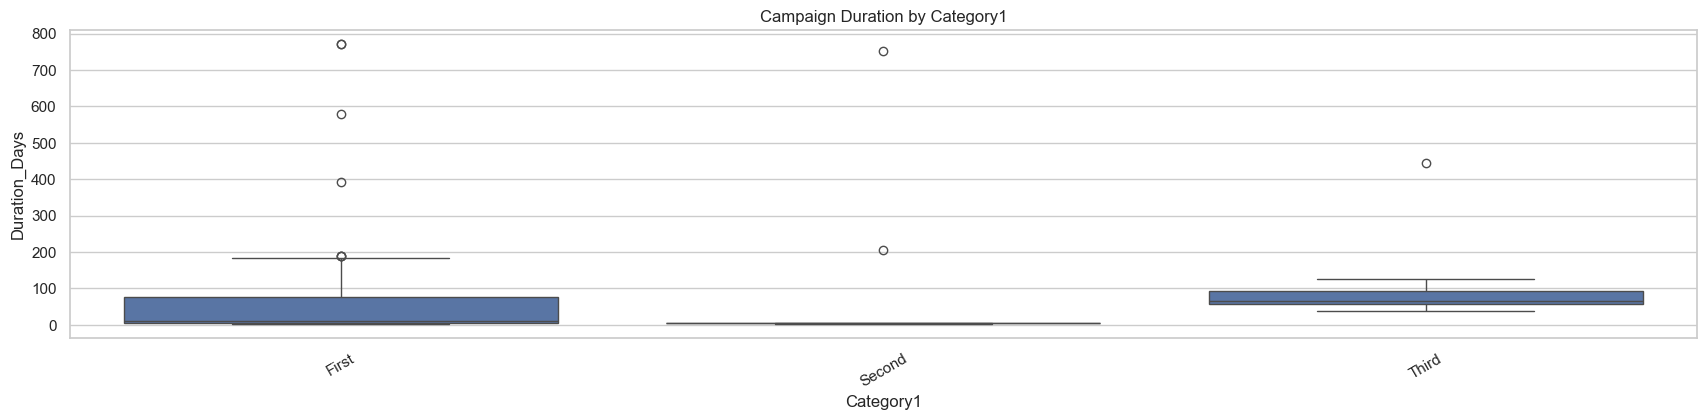

In [34]:
plt.figure(figsize=(21, 4))
sns.boxplot(x="Category1", y="Duration_Days", data=df)
plt.title("Campaign Duration by Category1")
plt.xticks(rotation=30)
plt.show()


## 8. Time-Based Analysis

Trend over time and seasonality across months/years.

In [35]:
monthly_counts = df.groupby("YearMonth").size().reset_index(name="Count")

fig = px.line(monthly_counts, x="YearMonth", y="Count", markers=True,
              title="Number of Campaigns Over Time")
fig.show()


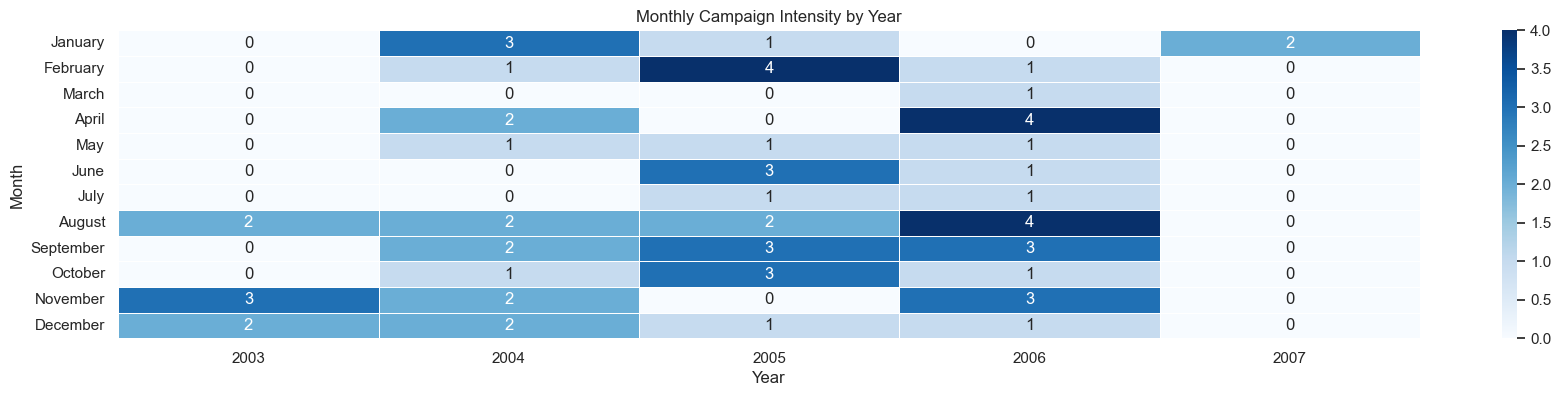

In [36]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

heatmap_data = df.groupby(["Year", "Month"]).size().reset_index(name="Count")
heatmap_data["Month"] = pd.Categorical(heatmap_data["Month"], categories=month_order, ordered=True)
heatmap_pivot = heatmap_data.pivot(index="Month", columns="Year", values="Count").fillna(0)

plt.figure(figsize=(21, 4))
sns.heatmap(heatmap_pivot, cmap="Blues", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Monthly Campaign Intensity by Year")
plt.show()


In [37]:
# Which year/month combination has the most campaigns?
top_period = heatmap_data.sort_values("Count", ascending=False).head(5)
top_period


,Year,Month,Count
14,2005,February,4
21,2006,April,4
22,2006,August,4
31,2006,September,3
2,2003,November,3


## 9. Key Insights & Summary

Fill this in after reviewing the outputs above — this is where the data analyst turns charts and numbers into takeaways. Example prompts to answer:

- Which `Category1` / `Category2` dominates campaign volume, and is that expected?
- Is campaign duration fairly consistent, or are there outliers worth investigating (very long or very short camps)?
- Is there a clear seasonal pattern (certain months consistently busier)?
- Is campaign volume trending up, down, or flat over time?
- Are there any data quality issues (invalid date ranges, missing values) that should be flagged to whoever owns this data?

**Example summary (replace with your own findings):**
> Campaign volume is concentrated in [Category], with an average duration of [X] days. Campaign counts peak around [month(s)], suggesting seasonal scheduling. [N] rows had unparseable dates or invalid date ranges and were excluded from this analysis — data quality at the source should be reviewed.


## 10. (Optional) Export Cleaned Data

Save the cleaned, feature-engineered dataset for reuse (e.g. in the Dash dashboard, or by other analysts).

In [38]:
OUTPUT_PATH = "./data/Health_Camp_Detail_cleaned.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned data saved to {OUTPUT_PATH}")


Cleaned data saved to ./data/Health_Camp_Detail_cleaned.csv
